# Airline Delay Prediction: DSC 148 Final Project
### By: Anwesha Mohanty & Akshitaa Balasai

**Predictive Task:** Regression: Predict `avg_delay_minutes_per_flight` for a carrier × airport × month × year combination

**Models:**

*Baselines:*
  1. Mean Predictor (Naïve Bayes analog)
  2. Linear Regression

*Final:*

  3. Random Forest Regressor


**Evaluation Metrics:**

RMSE, MAE, R²

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

print('Imports Completed!')

Imports Completed!


## 2. Load Data

In [ ]:
airlines_df = pd.read_csv('Airline_Delay_Cause_cleaned_sample_60k.csv')
print(f'Shape: {airlines_df.shape}')
airlines_df.head()

Shape: (60000, 26)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate,cancel_rate,diversion_rate,avg_delay_minutes_per_flight,high_delay
0,2007,3,NW,Northwest Airlines Inc.,MOT,"Minot, ND: Minot International",93.0,38.0,18.13,0.00,...,771.0,0.0,409.0,0.0,457.0,0.408602,0.043011,0.000000,17.602151,1
1,2005,12,OO,SkyWest Airlines Inc.,ALB,"Albany, NY: Albany International",49.0,14.0,6.00,1.00,...,184.0,143.0,546.0,0.0,276.0,0.285714,0.040816,0.020408,23.448980,1
2,2009,1,9E,Pinnacle Airlines Inc.,GRR,"Grand Rapids, MI: Gerald R. Ford International",183.0,26.0,8.98,0.00,...,657.0,0.0,212.0,0.0,599.0,0.142077,0.027322,0.005464,8.021858,0
3,2010,11,MQ,American Eagle Airlines Inc.,GRK,"Killeen, TX: Robert Gray AAF",220.0,22.0,10.95,2.21,...,456.0,110.0,189.0,0.0,318.0,0.100000,0.004545,0.000000,4.877273,0
4,2019,4,MQ,Envoy Air,HSV,"Huntsville, AL: Huntsville International-Carl ...",30.0,2.0,0.50,0.00,...,17.0,0.0,53.0,0.0,7.0,0.066667,0.000000,0.000000,2.566667,0


## 3. Feature Engineering

We use only use features that had nothing that is a direct component of the target.
The delay sub-columns (`carrier_delay`, `weather_delay`, etc.) and `arr_delay` are excluded because they are used to make the targeet variable `avg_delay_minutes_per_flight`.

In [ ]:
# Features and target
CATEGORICAL_FEATURES = ['carrier', 'airport', 'month']
NUMERIC_FEATURES = ['year', 'arr_flights', 'cancel_rate', 'diversion_rate', 'delay_rate']
TARGET = 'avg_delay_minutes_per_flight'

FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

# Drop extreme outliers (top 0.1%) to prevent skewed evaluation
upper = airlines_df[TARGET].quantile(0.999)
airlines_df_clean = airlines_df[airlines_df[TARGET] <= upper].copy()
print(f'Removed {len(airlines_df) - len(airlines_df_clean)} extreme outlier rows (>{upper:.1f} min)')
print(f'Clean dataset: {airlines_df_clean.shape}')

Removed 60 extreme outlier rows (>95.7 min)
Clean dataset: (59940, 26)


## 4. Train / Test Split

We use a standard **random 80/20 split** with a fixed random seed for reproducibility.

In [ ]:
from sklearn.model_selection import train_test_split

X = airlines_df_clean[FEATURES]
y = airlines_df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Keep a copy of test rows for error analysis later
test = airlines_df_clean.loc[X_test.index]

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (47952, 8)  |  Test: (11988, 8)


## 5. Evaluation Function

This function is used to evalute and output all of the evaluation metrics for each model.

In [ ]:
results = {}

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2}
    print(f'{name}')
    print(f'  RMSE : {rmse:.4f} min')
    print(f'  MAE  : {mae:.4f} min')
    print(f'  R²   : {r2:.4f}')
    return rmse, mae, r2

## 6. Baseline Model 1: Mean Predictor

This model predicts the **global training mean** for every sample. This is the regression analog of a Naïve Bayes model with no feature information. It captures only the unconditional distribution of the target and assumes all features are irrelevant.

In [ ]:
mean_model = DummyRegressor(strategy='mean')
mean_model.fit(X_train[NUMERIC_FEATURES], y_train)
y_pred_mean = mean_model.predict(X_test[NUMERIC_FEATURES])

evaluate('Baseline 1: Mean Predictor', y_test, y_pred_mean)

Baseline 1: Mean Predictor
  RMSE : 8.6473 min
  MAE  : 6.2175 min
  R²   : -0.0001


(np.float64(8.64726634073354), 6.2174538573291525, -9.901881568175064e-05)

## 7. Baseline Model 2: Linear Regression

This model assumes delay is a **linear combination** of carrier, airport, month, and numeric features. Categorical features are one-hot encoded.

In [ ]:
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ('num', 'passthrough', NUMERIC_FEATURES)
])

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=1.0))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

evaluate('Baseline 2: Linear Regression (Ridge)', y_test, y_pred_lr)

Baseline 2: Linear Regression (Ridge)
  RMSE : 5.0377 min
  MAE  : 2.9679 min
  R²   : 0.6606


(np.float64(5.037705941315844), 2.9678947792634145, 0.6605694274308209)

In [2]:
# Top 15 most influential features
ohe_feature_names = lr_pipeline.named_steps['prep'].transformers_[0][1].get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = list(ohe_feature_names) + NUMERIC_FEATURES
coefs = lr_pipeline.named_steps['model'].coef_

coef_airlines_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs})
coef_airlines_df = coef_airlines_df.reindex(coef_airlines_df['coefficient'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 5))
top15 = coef_airlines_df.head(15)
colors = ['#185FA5' if c > 0 else '#D85A30' for c in top15['coefficient']]
plt.barh(top15['feature'][::-1], top15['coefficient'][::-1], color=colors[::-1])
plt.xlabel('Coefficient value')
plt.title('Linear Regression: top 15 coefficients by magnitude')
plt.tight_layout()
plt.show()

NameError: name 'lr_pipeline' is not defined

## 8. Final Model: Random Forest Regressor

Random Forest builds many decision trees on random subsets of the data (bagging) and averages their predictions. Unlike linear regression, it can capture:
- **Nonlinear effects** (e.g., delay spikes in summer months but only for certain carriers)
- **Interaction effects** between carrier, airport, and season without manual feature engineering
- **High-cardinality categoricals** like airport codes without assuming linearity

Categorical features are ordinal-encoded (integer codes), which Random Forest handles natively since it splits on thresholds rather than distances.

In [ ]:
# Ordinal encode categoricals for Random Forest
prep_rf = ColumnTransformer([
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), CATEGORICAL_FEATURES),
    ('num', 'passthrough', NUMERIC_FEATURES)
])

rf_pipeline = Pipeline([
    ('prep', prep_rf),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=5,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

evaluate('Final: Random Forest', y_test, y_pred_rf)

Proposed: Random Forest
  RMSE : 4.9196 min
  MAE  : 2.8516 min
  R²   : 0.6763


(np.float64(4.919582179578614), 2.8515665017407517, 0.6763006933600018)

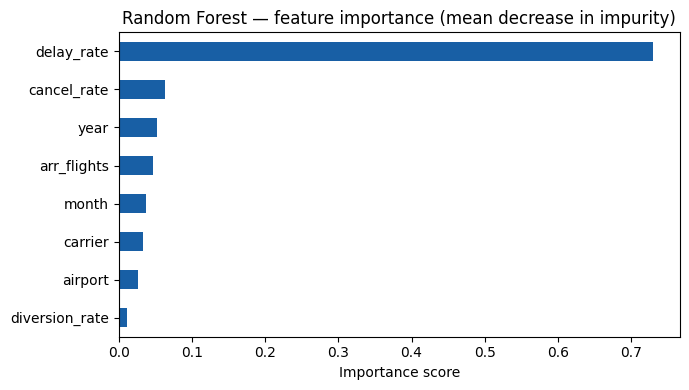

In [ ]:
# Feature importance
fi = pd.Series(
    rf_pipeline.named_steps['model'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
fi.plot(kind='barh', color='#185FA5')
plt.title('Random Forest: feature importance (mean decrease in impurity)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

## 9. Comparing the Models

In [ ]:
comparison_df = pd.DataFrame(results).T.round(4)
comparison_df.index.name = 'Model'
print(comparison_df.to_string())
comparison_df

                                         RMSE     MAE      R²
Model                                                        
Baseline 1: Mean Predictor             8.6473  6.2175 -0.0001
Baseline 2: Linear Regression (Ridge)  5.0377  2.9679  0.6606
Proposed: Random Forest                4.9196  2.8516  0.6763


,RMSE,MAE,R²
Model,,,
Baseline 1: Mean Predictor,8.6473,6.2175,-0.0001
Baseline 2: Linear Regression (Ridge),5.0377,2.9679,0.6606
Proposed: Random Forest,4.9196,2.8516,0.6763


### Evaluation metrics

| Metric | What it measures | Lower or higher is better |
|---|---|---|
| **RMSE** (Root Mean Squared Error) | Average prediction error in minutes, with larger errors penalized more heavily | Lower is better |
| **MAE** (Mean Absolute Error) | Average prediction error in minutes, treating all errors equally | Lower is better |
| **R²** (Coefficient of Determination) | How much of the variance in delay minutes the model explains | Higher is better (max = 1.0) |

**Evaluation Summary**

- The Mean Predictor performs worst across all metrics as its negative R² confirms it does no better than guessing the average.
- Linear Regression improves significantly, with RMSE dropping from 8.65 to 5.04 and R² of 0.66.
- Random Forest performs best with the lowest RMSE (4.92) and highest R² (0.68), showing that capturing nonlinear feature interactions leads to better predictions.

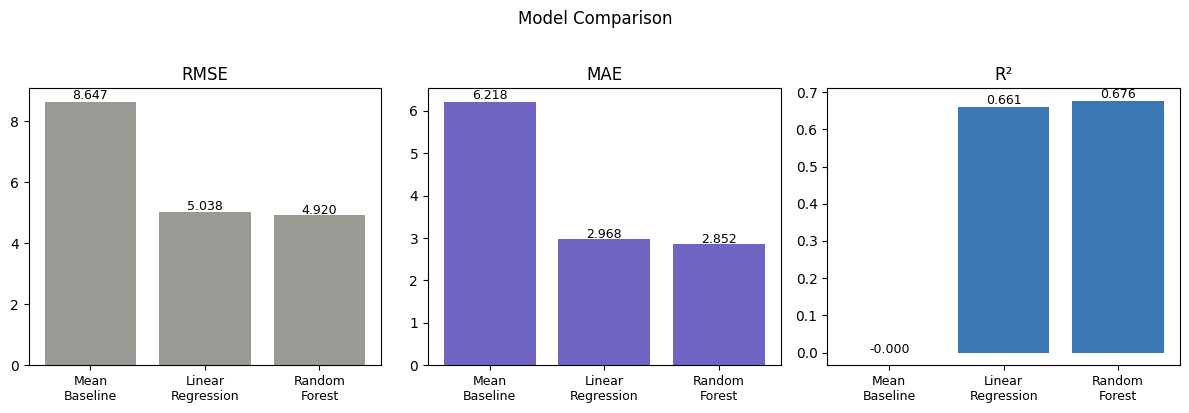

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ['RMSE', 'MAE', 'R²']
colors_bar = ['#888780', '#534AB7', '#185FA5']

for ax, metric, color in zip(axes, metrics, colors_bar):
    vals = comparison_df[metric]
    ax.bar(range(len(vals)), vals, color=color, alpha=0.85)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['Mean\nBaseline', 'Linear\nRegression', 'Random\nForest'], fontsize=9)
    ax.set_title(metric)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01 * abs(v), f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', y=1.02)
plt.tight_layout()
plt.show()

## 10. Ablation Study

Remove one feature group at a time and measure the RMSE increase to quantify each group's contribution.

In [ ]:
ablation_groups = {
    'No carrier':    [f for f in FEATURES if f != 'carrier'],
    'No airport':    [f for f in FEATURES if f != 'airport'],
    'No month':      [f for f in FEATURES if f != 'month'],
    'No delay_rate': [f for f in FEATURES if f != 'delay_rate'],
    'No year':       [f for f in FEATURES if f != 'year'],
}

full_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
ablation_results = {'Full model': full_rmse}

for label, feats in ablation_groups.items():
    cat_feats = [c for c in CATEGORICAL_FEATURES if c in feats]
    num_feats = [c for c in NUMERIC_FEATURES if c in feats]
    prep_abl = ColumnTransformer([
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_feats),
        ('num', 'passthrough', num_feats)
    ])
    pipe_abl = Pipeline([
        ('prep', prep_abl),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5,
                                         max_features='sqrt', n_jobs=-1, random_state=42))
    ])
    pipe_abl.fit(X_train[feats], y_train)
    rmse = np.sqrt(mean_squared_error(y_test, pipe_abl.predict(X_test[feats])))
    ablation_results[label] = rmse
    print(f'{label:20s} RMSE: {rmse:.4f}  (Δ vs full: +{rmse - full_rmse:.4f})')

print(f'\n{"Full model":20s} RMSE: {full_rmse:.4f}')

No carrier           RMSE: 4.9975  (Δ vs full: +0.0779)
No airport           RMSE: 4.8986  (Δ vs full: +-0.0210)
No month             RMSE: 4.9310  (Δ vs full: +0.0114)
No delay_rate        RMSE: 7.5015  (Δ vs full: +2.5819)
No year              RMSE: 5.1058  (Δ vs full: +0.1862)

Full model           RMSE: 4.9196


In [1]:
abl_airlines_df = pd.Series(ablation_results).sort_values()
colors_abl = ['#185FA5' if k == 'Full model' else '#888780' for k in abl_airlines_df.index]

plt.figure(figsize=(7, 4))
abl_airlines_df.plot(kind='barh', color=colors_abl)
plt.xlabel('RMSE (min)')
plt.title('Ablation study: RMSE when each feature group is removed')
plt.axvline(full_rmse, color='#D85A30', linestyle='--', linewidth=1, label='Full model')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

## 11. Case Study: Where does the model perform well and poorly?


### Error Analysis

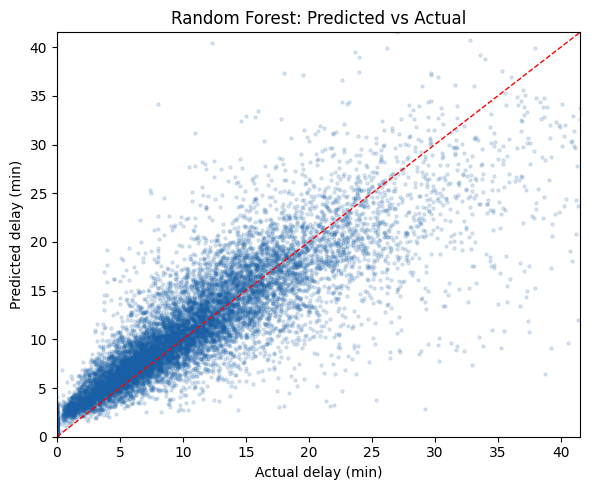

In [ ]:
performance_df = test.copy()
performance_df['predicted'] = y_pred_rf
performance_df['error'] = performance_df['predicted'] - performance_df[TARGET]
performance_df['abs_error'] = performance_df['error'].abs()

# Predicted vs Actual
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.15, s=5, color='#185FA5')
lims = [0, y_test.quantile(0.99)]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Actual delay (min)')
plt.ylabel('Predicted delay (min)')
plt.title('Random Forest: Predicted vs Actual')
plt.xlim(lims); plt.ylim(lims)
plt.tight_layout()
plt.show()

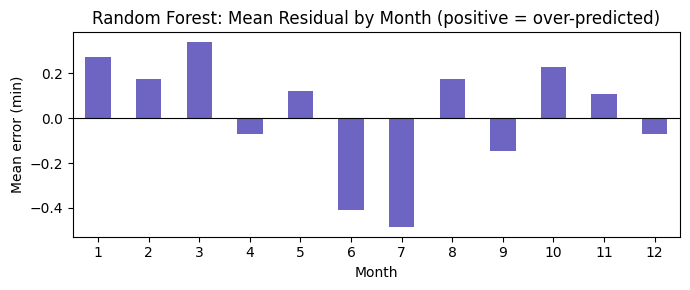

In [ ]:
# Residuals by month
monthly_err = performance_df.groupby('month')['error'].mean()
plt.figure(figsize=(7, 3))
monthly_err.plot(kind='bar', color='#534AB7', alpha=0.85)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Month')
plt.ylabel('Mean error (min)')
plt.title('Random Forest: Mean Residual by Month (positive = over-predicted)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Worst Predictions: Where does the model perform the worst?

In [ ]:
# Worst predicted cases
print('Top 10 largest absolute errors:')
performance_df.nlargest(10, 'abs_error')[['year','month','carrier','airport',TARGET,'predicted','error']].round(2)

Top 10 largest absolute errors:


,year,month,carrier,airport,avg_delay_minutes_per_flight,predicted,error
4126,2022,12,YV,PHL,95.67,21.45,-74.22
42024,2017,12,NK,PBG,81.45,18.38,-63.08
17240,2021,1,G4,GSP,64.83,5.57,-59.27
34892,2013,9,EV,MDW,76.00,16.94,-59.06
31665,2020,7,G4,PSM,75.69,17.82,-57.87
40446,2019,7,UA,BUR,84.14,29.73,-54.40
29292,2019,1,G7,CPR,80.19,25.89,-54.30
54149,2004,6,FL,ICT,92.00,39.73,-52.27
36567,2009,3,YV,GSO,88.00,36.00,-52.00
43956,2024,6,OO,HOB,86.60,34.82,-51.78


### Best Predictions: Where does the model perform the best?

In [ ]:
# Best predicted cases
print('Top 10 smallest absolute errors (model performs best):')
performance_df.nsmallest(10, 'abs_error')[['year','month','carrier','airport',TARGET,'predicted','error']].round(2)

Top 10 smallest absolute errors (model performs best):


,year,month,carrier,airport,avg_delay_minutes_per_flight,predicted,error
8799,2016,9,DL,EWR,9.65,9.65,-0.0
33312,2008,11,YV,EGE,5.57,5.57,-0.0
9862,2023,11,UA,LAX,6.53,6.53,0.0
9723,2019,5,WN,GEG,12.13,12.13,0.0
15292,2013,1,OO,MSP,8.11,8.11,-0.0
54783,2009,1,9E,FLL,15.57,15.56,-0.0
22610,2003,11,CO,TPA,5.09,5.09,0.0
58620,2018,9,YX,CHS,7.86,7.86,-0.0
53774,2006,1,NW,MSP,7.46,7.46,-0.0
1170,2016,1,NK,SAN,16.74,16.74,0.0


## 12. Summary

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Mean Predictor | 8.6473 | 6.2175 | -0.0001 |
| Linear Regression | 5.0377 | 2.9679 | 0.6606 |
| Random Forest | 4.9196 | 2.8516 | 0.6763 |

**Key takeaways:**
- **Random Forest** outperforms both baselines across all metrics, demonstrating that nonlinear interactions between carrier, airport, and season add predictive value.

- `delay_rate` is by far the most critical feature since removing it significantly raised the RMSE from 4.92 to 7.50
- `carrier` and `year` were also secondary contributing features, while `airport` and `month` had minimal contribution.
- Extreme outliers were difficult to predict. A potential next step would be to explore a log-transformed target.